In [2]:
import json
import pandas as pd
target_path = '/Users/debanjansarkar/Desktop/Boot_Camps/spring-2026-LLM-hallucinations/data/processed_halueval_t1.0_n20.jsonl'

In [3]:
# Build dataframe
df = pd.read_json(target_path, lines=True)

In [5]:
display(df.keys())
display(df.head())

Index(['id', 'prompt_id', 'sample_num', 'dataset', 'question',
       'reference_answer', 'model_answer', 'temperature', 'prompt_tokens',
       'generated_tokens', 'timestamp', 'type', 'domain', 'correctness'],
      dtype='object')

,id,prompt_id,sample_num,dataset,question,reference_answer,model_answer,temperature,prompt_tokens,generated_tokens,timestamp,type,domain,correctness
0,halueval_00000_t1.0_ans00,halueval_00000_t1.0,sample00,halueval,Context: He also played non-league football f...,Grantham Town Football Club,Grantham Town.,1,145,128,2026-02-26 22:07:06+00:00,,General Knowledge,correct
1,halueval_00000_t1.0_ans01,halueval_00000_t1.0,sample01,halueval,Context: He also played non-league football f...,Grantham Town Football Club,Grantham Town,1,145,128,2026-02-26 22:07:06+00:00,,General Knowledge,correct
2,halueval_00000_t1.0_ans02,halueval_00000_t1.0,sample02,halueval,Context: He also played non-league football f...,Grantham Town Football Club,Grantham Town Football Club,1,145,128,2026-02-26 22:07:06+00:00,,General Knowledge,correct
3,halueval_00000_t1.0_ans03,halueval_00000_t1.0,sample03,halueval,Context: He also played non-league football f...,Grantham Town Football Club,Grantham Town,1,145,128,2026-02-26 22:07:06+00:00,,General Knowledge,correct
4,halueval_00000_t1.0_ans04,halueval_00000_t1.0,sample04,halueval,Context: He also played non-league football f...,Grantham Town Football Club,Grantham Town Football Club,1,145,128,2026-02-26 22:07:06+00:00,,General Knowledge,correct


# Hallucination Detection on HaluEval via Semantic Entropy & Embedding Geometry

This notebook applies the same Stage 3-4 pipeline we used for DefAn, now on the HaluEval dataset.
The processing is identical: Llama-3B generated 20 responses per prompt at temperature 1.0,
and GPT-4-mini judged each response.

Key differences from DefAn:

- HaluEval questions are context-grounded: each prompt includes a knowledge passage
  (from HotpotQA or similar) followed by a question. This makes hallucination detection
  conceptually closer to the faithfulness setting than pure factual recall.
- The original HaluEval benchmark (Li et al., 2023) spans QA, dialogue, and summarization
  tasks with 35K samples. Our processed version runs the same generation+judge pipeline
  on the QA portion.
- The `type` column may be empty or sparse, unlike DefAn which had date/numeric/name/location.
  We handle this gracefully.

The correctness labels from the judge can include: correct, hallucination, refused, illogical.
We use the same strict labeling as DefAn: the binary classification target counts only
correct vs hallucination responses (excluding refused/illogical from the majority vote).

References: Farquhar et al. (2024), Ricco et al. (2025), Lee et al. (2018), Li et al. (2023)

## Setup

In [ ]:
# Uncomment if needed:
# !pip install -q sentence-transformers scikit-learn xgboost scipy shap matplotlib seaborn umap-learn

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
from matplotlib.lines import Line2D
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn not installed, UMAP plots will be skipped.')

print('Imports loaded.')

Imports loaded.


In [2]:
DATA_PATH = '/Users/debanjansarkar/Desktop/Boot_Camps/spring-2026-LLM-hallucinations/data/processed_halueval_t1.0_n20.jsonl'
EMBED_CACHE = 'halueval_embeddings.npy'
OUTPUT_DIR = 'halueval_output'

SIM_THRESHOLD = 0.85
N_PERMUTATIONS = 10000
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

GEO_FEATURES = ['H_sem', 'D_cos', 'M_bar', 'K', 'sig2_S']

LABEL_COLORS = {
    'correct': '#2196F3',
    'hallucination': '#E53935',
    'refused': '#FFA726',
    'illogical': '#78909C',
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

## Load Data

In [3]:
df = pd.read_json(DATA_PATH, lines=True)
print(f'Total rows: {len(df)}')
print(f'Unique questions: {df["prompt_id"].nunique()}')
print(f'Domains: {sorted(df["domain"].dropna().unique())}')
print()

# check the type column -- in HaluEval it may be empty
type_vals = df['type'].dropna().replace('', pd.NA).dropna().unique()
if len(type_vals) > 0:
    print(f'Answer types: {sorted(type_vals)}')
else:
    print('Answer type column is empty (expected for HaluEval).')
    # create a placeholder so downstream code doesn't break
    df['type'] = 'qa'
print()

print('Correctness distribution (response-level):')
print(df['correctness'].value_counts())
print()

spq = df.groupby('prompt_id').size()
print(f'Samples per question -- min: {spq.min()}, max: {spq.max()}, median: {spq.median()}')

Total rows: 10000
Unique questions: 500
Domains: ['Arts & Literature', 'Computer Science & Engineering', 'Economics & Business', 'General Knowledge', 'History & Geography', 'Life Sciences', 'Philosophy & Religion', 'Physical Sciences', 'Politics & Law', 'error']

Answer type column is empty (expected for HaluEval).

Correctness distribution (response-level):
correctness
correct          8614
hallucination     979
error             200
refused           117
illogical          90
Name: count, dtype: int64

Samples per question -- min: 20, max: 20, median: 20.0


In [4]:
# peek at the data -- the question column includes the context passage
print('Example question (first 500 chars):')
print(df.iloc[0]['question'][:500])
print()
print(f'Reference answer: {df.iloc[0]["reference_answer"]}')
print(f'Model answer:     {df.iloc[0]["model_answer"]}')
print(f'Correctness:      {df.iloc[0]["correctness"]}')

Example question (first 500 chars):
Context:  He also played non-league football for Grantham Town, Boston United, Shepshed Albion, Harworth Colliery Institute, Brigg Town, Armthorpe Welfare, Glapwell, Collingham (Notts) and Retford United.Grantham Town Football Club is a football club, based in Grantham, Lincolnshire, England.

Question: Simon WIlliam Gamble played non league football for what club located in Lincolnshire, England?

Reference answer: Grantham Town Football Club
Model answer:     Grantham Town.
Correctness:      correct


## Response-Level EDA: All Judge Labels

We start by looking at the distribution of all four correctness labels across the dataset.
HaluEval questions are context-grounded, so we'd expect a different refusal and hallucination
profile than DefAn: the model has the answer passage right there in the prompt, which may
reduce refusals but could increase subtle hallucinations where the model drifts from the
provided context.

In [5]:
# determine which labels actually exist
ALL_LABELS = [l for l in ['correct', 'hallucination', 'refused', 'illogical']
              if l in df['correctness'].values]
print(f'Labels present: {ALL_LABELS}')

resp_counts = df['correctness'].value_counts()
resp_pcts = (resp_counts / len(df) * 100).round(1)
print()
print('Response-level label distribution:')
for lab in ALL_LABELS:
    if lab in resp_counts.index:
        print(f'  {lab:15s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')

Labels present: ['correct', 'hallucination', 'refused', 'illogical']

Response-level label distribution:
  correct        :   8614  (86.1%)
  hallucination  :    979  (9.8%)
  refused        :    117  (1.2%)
  illogical      :     90  (0.9%)


In [6]:
# cross-tab: domain x correctness
ct_domain = pd.crosstab(df['domain'], df['correctness'])
ct_domain = ct_domain.reindex(columns=[c for c in ALL_LABELS if c in ct_domain.columns])
print('Response counts by domain x correctness:')
display(ct_domain)
print()

ct_domain_pct = ct_domain.div(ct_domain.sum(axis=1), axis=0)
print('Proportions:')
display(ct_domain_pct.round(3))

Response counts by domain x correctness:


correctness,correct,hallucination,refused,illogical
domain,,,,
Arts & Literature,2501,355,25,17
Computer Science & Engineering,56,4,0,0
Economics & Business,186,4,2,1
General Knowledge,3317,358,61,63
History & Geography,1775,195,23,3
Life Sciences,255,29,0,0
Philosophy & Religion,58,0,0,0
Physical Sciences,47,12,1,0
Politics & Law,419,22,5,6



Proportions:


correctness,correct,hallucination,refused,illogical
domain,,,,
Arts & Literature,0.863,0.122,0.009,0.006
Computer Science & Engineering,0.933,0.067,0.000,0.000
Economics & Business,0.964,0.021,0.010,0.005
General Knowledge,0.873,0.094,0.016,0.017
History & Geography,0.889,0.098,0.012,0.002
Life Sciences,0.898,0.102,0.000,0.000
Philosophy & Religion,1.000,0.000,0.000,0.000
Physical Sciences,0.783,0.200,0.017,0.000
Politics & Law,0.927,0.049,0.011,0.013


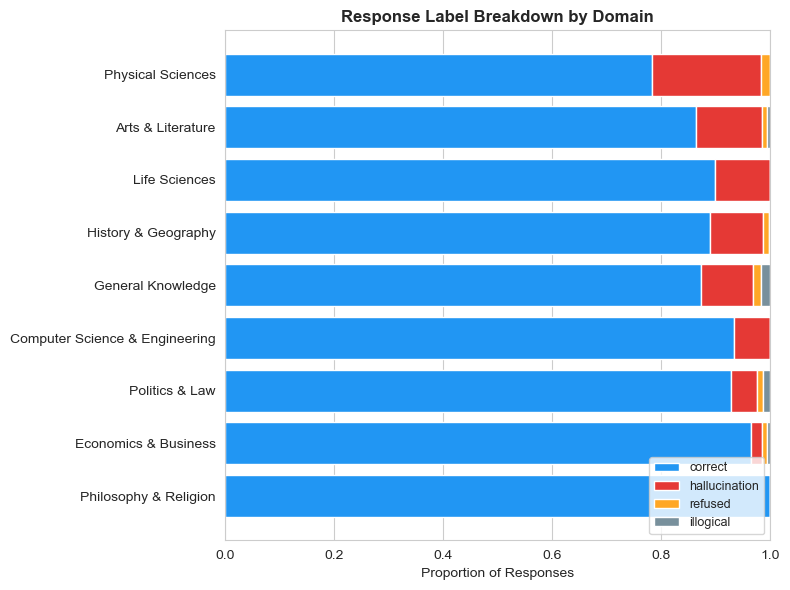

In [7]:
# stacked bar: domain x label proportions

n_panels = 2 if len(df['type'].unique()) > 1 and df['type'].iloc[0] != 'qa' else 1

fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 6))
if n_panels == 1:
    axes = [axes]

# panel 1: by domain
ct_plot = ct_domain_pct.sort_values(ct_domain_pct.columns[0] if 'hallucination' not in ct_domain_pct.columns else 'hallucination',
                                     ascending=True)
bottom = np.zeros(len(ct_plot))
for lab in ALL_LABELS:
    if lab not in ct_plot.columns:
        continue
    vals = ct_plot[lab].values
    axes[0].barh(ct_plot.index, vals, left=bottom,
                 color=LABEL_COLORS.get(lab, 'gray'), label=lab)
    bottom += vals
axes[0].set_xlabel('Proportion of Responses')
axes[0].set_title('Response Label Breakdown by Domain', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim(0, 1)

# panel 2: by type (if meaningful)
if n_panels == 2:
    ct_type = pd.crosstab(df['type'], df['correctness'])
    ct_type = ct_type.reindex(columns=[c for c in ALL_LABELS if c in ct_type.columns])
    ct_type_pct = ct_type.div(ct_type.sum(axis=1), axis=0)
    ct_type_pct = ct_type_pct.sort_values('hallucination', ascending=True)
    bottom = np.zeros(len(ct_type_pct))
    for lab in ALL_LABELS:
        if lab not in ct_type_pct.columns:
            continue
        vals = ct_type_pct[lab].values
        axes[1].barh(ct_type_pct.index, vals, left=bottom,
                     color=LABEL_COLORS.get(lab, 'gray'), label=lab)
        bottom += vals
    axes[1].set_xlabel('Proportion of Responses')
    axes[1].set_title('Response Label Breakdown by Type', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)
    axes[1].set_xlim(0, 1)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_response_label_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

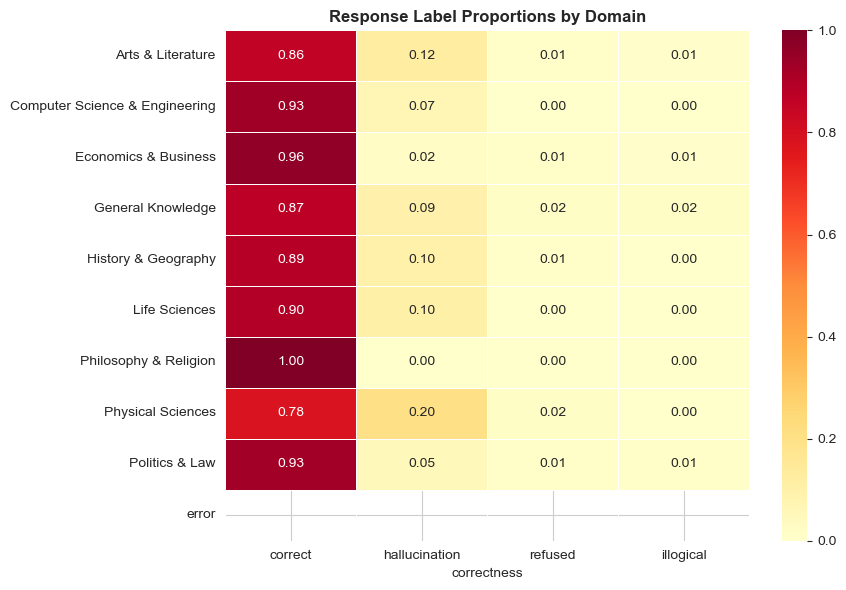

In [8]:
# heatmap
fig, ax = plt.subplots(figsize=(9, max(4, len(ct_domain_pct) * 0.5 + 1)))
sns.heatmap(ct_domain_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Response Label Proportions by Domain', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_response_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Stage 3a: Embed All Responses

We embed the `model_answer` field (not the full question+context). The context passage
can be very long and would dominate the embedding; we want to capture the geometry
of what the model actually said.

In [9]:
if os.path.exists(EMBED_CACHE):
    print(f'Loading cached embeddings from {EMBED_CACHE}')
    all_embeddings = np.load(EMBED_CACHE)
    assert all_embeddings.shape[0] == len(df), 'Cache size mismatch!'
else:
    print('Computing embeddings...')
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    texts = df['model_answer'].astype(str).tolist()
    all_embeddings = embedder.encode(texts, batch_size=256,
                                     show_progress_bar=True,
                                     normalize_embeddings=True)
    np.save(EMBED_CACHE, all_embeddings)
    print(f'Saved to {EMBED_CACHE}')

print(f'Embedding matrix: {all_embeddings.shape}')

Computing embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Saved to halueval_embeddings.npy
Embedding matrix: (10000, 384)


## Stage 3b: Feature Extraction

Same 5 geometric features computed from all 20 response embeddings per question:

1. Semantic entropy $H_{sem}$ -- Shannon entropy over cluster proportions
2. Cosine dispersion $D_{cos}$ -- mean cosine distance from centroid
3. Mahalanobis distance $\bar{M}$ -- distance from the correct-response reference distribution
4. Cluster count $K$
5. Similarity variance $\sigma^2_S$

Binary label uses strict correct-vs-hallucination vote, excluding refused and illogical.

In [10]:
def semantic_entropy(embs, threshold=SIM_THRESHOLD):
    n = len(embs)
    dist_matrix = np.clip(1.0 - cosine_similarity(embs), 0, 2)
    np.fill_diagonal(dist_matrix, 0)
    clustering = AgglomerativeClustering(
        n_clusters=None, metric='precomputed',
        linkage='average', distance_threshold=1 - threshold
    )
    labels = clustering.fit_predict(dist_matrix)
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / n
    H = -np.sum(probs * np.log2(probs + 1e-12))
    return H, len(counts)


def cosine_dispersion(embs):
    centroid = embs.mean(axis=0, keepdims=True)
    return float(np.mean(1.0 - cosine_similarity(embs, centroid).flatten()))


def mahalanobis_distance(embs, mu, cov_inv):
    diffs = embs - mu
    mahal_sq = np.einsum('ni,ij,nj->n', diffs, cov_inv, diffs)
    mahal_sq = np.clip(mahal_sq, 0, None)
    return float(np.mean(np.sqrt(mahal_sq)))


def similarity_variance(embs):
    sim = cosine_similarity(embs)
    upper = sim[np.triu_indices(len(embs), k=1)]
    return float(np.var(upper))

In [11]:
# fit reference distribution on correct-labeled responses
correct_mask = (df['correctness'] == 'correct').values
correct_embs = all_embeddings[correct_mask]
print(f'Correct responses for reference: {correct_embs.shape[0]}')

if correct_embs.shape[0] < 10:
    print('WARNING: very few correct responses. Using all embeddings for reference.')
    correct_embs = all_embeddings

mu_ref = correct_embs.mean(axis=0)
lw = LedoitWolf()
lw.fit(correct_embs)
cov_inv = lw.precision_
print(f'Reference fitted. mu: {mu_ref.shape}, precision: {cov_inv.shape}')

Correct responses for reference: 8614
Reference fitted. mu: (384,), precision: (384, 384)


In [12]:
prompt_ids = df['prompt_id'].unique()
records = []
skipped = 0

for i, pid in enumerate(prompt_ids):
    if (i + 1) % 500 == 0:
        print(f'  {i+1}/{len(prompt_ids)} ...')

    mask = df['prompt_id'] == pid
    sub = df[mask]
    idx = np.where(mask.values)[0]
    embs = all_embeddings[idx]
    n = len(sub)

    # count each label
    counts = sub['correctness'].value_counts()
    n_correct   = int(counts.get('correct', 0))
    n_hallu     = int(counts.get('hallucination', 0))
    n_refused   = int(counts.get('refused', 0))
    n_illogical = int(counts.get('illogical', 0))

    # strict label: majority vote on correct vs hallucination only
    n_definitive = n_correct + n_hallu
    if n_definitive == 0:
        skipped += 1
        continue

    hall_rate_strict = n_hallu / n_definitive
    label = 1 if hall_rate_strict > 0.5 else 0

    # geometric features from all 20 embeddings
    H, K = semantic_entropy(embs)
    D = cosine_dispersion(embs)
    M = mahalanobis_distance(embs, mu_ref, cov_inv)
    sig2 = similarity_variance(embs)

    row0 = sub.iloc[0]
    records.append({
        'prompt_id': pid,
        'question': row0['question'],
        'domain': row0['domain'],
        'type': row0['type'],
        'n_samples': n,
        'n_correct': n_correct,
        'n_hallu': n_hallu,
        'n_refused': n_refused,
        'n_illogical': n_illogical,
        'n_definitive': n_definitive,
        'frac_correct': n_correct / n,
        'frac_hallu': n_hallu / n,
        'frac_refused': n_refused / n,
        'frac_illogical': n_illogical / n,
        'hall_rate_strict': hall_rate_strict,
        'hall_rate_naive': 1.0 - (n_correct / n),
        'H_sem': H,
        'D_cos': D,
        'M_bar': M,
        'K': K,
        'sig2_S': sig2,
        'label': label,
    })

feat_df = pd.DataFrame(records)
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'halueval_features.csv'), index=False)

print(f'\nQuestions processed: {len(feat_df)}')
print(f'Questions skipped (all refused/illogical): {skipped}')
print(f'Label distribution:')
print(f'  Correct (label=0): {(feat_df["label"]==0).sum()}')
print(f'  Hallucinated (label=1): {(feat_df["label"]==1).sum()}')
print(f'  Rate: {feat_df["label"].mean()*100:.1f}%')

  500/500 ...

Questions processed: 499
Questions skipped (all refused/illogical): 1
Label distribution:
  Correct (label=0): 457
  Hallucinated (label=1): 42
  Rate: 8.4%


## Question-Level EDA: Label Profiles

In [13]:
frac_cols = ['frac_correct', 'frac_hallu', 'frac_refused', 'frac_illogical']

print('Per-question label fraction statistics:')
print(feat_df[frac_cols].describe().round(3).to_string())
print()

# determine grouping column -- use domain if it has >1 unique value, else skip domain breakdowns
domains_list = sorted(feat_df['domain'].dropna().replace('', pd.NA).dropna().unique())
HAS_DOMAINS = len(domains_list) > 1
print(f'Domains found: {len(domains_list)}')
if HAS_DOMAINS:
    print(domains_list)
    domain_fracs = feat_df.groupby('domain')[frac_cols].mean().sort_values('frac_hallu', ascending=False)
    display(domain_fracs.round(3))
else:
    print('Single domain -- domain breakdowns will use the full dataset.')
    # still keep the list so loops don't break
    if len(domains_list) == 0:
        domains_list = ['all']
        feat_df['domain'] = 'all'

Per-question label fraction statistics:
       frac_correct  frac_hallu  frac_refused  frac_illogical
count       499.000     499.000       499.000         499.000
mean          0.863       0.098         0.012           0.007
std           0.240       0.211         0.067           0.039
min           0.000       0.000         0.000           0.000
25%           0.850       0.000         0.000           0.000
50%           0.950       0.000         0.000           0.000
75%           1.000       0.050         0.000           0.000
max           1.000       1.000         0.750           0.550

Domains found: 10
['Arts & Literature', 'Computer Science & Engineering', 'Economics & Business', 'General Knowledge', 'History & Geography', 'Life Sciences', 'Philosophy & Religion', 'Physical Sciences', 'Politics & Law', 'error']


,frac_correct,frac_hallu,frac_refused,frac_illogical
domain,,,,
Physical Sciences,0.783,0.200,0.017,0.000
Arts & Literature,0.842,0.125,0.010,0.005
Life Sciences,0.858,0.115,0.000,0.000
History & Geography,0.860,0.104,0.017,0.002
General Knowledge,0.871,0.084,0.013,0.012
Computer Science & Engineering,0.933,0.067,0.000,0.000
Politics & Law,0.900,0.057,0.011,0.018
error,0.864,0.029,0.000,0.000
Economics & Business,0.965,0.020,0.000,0.005


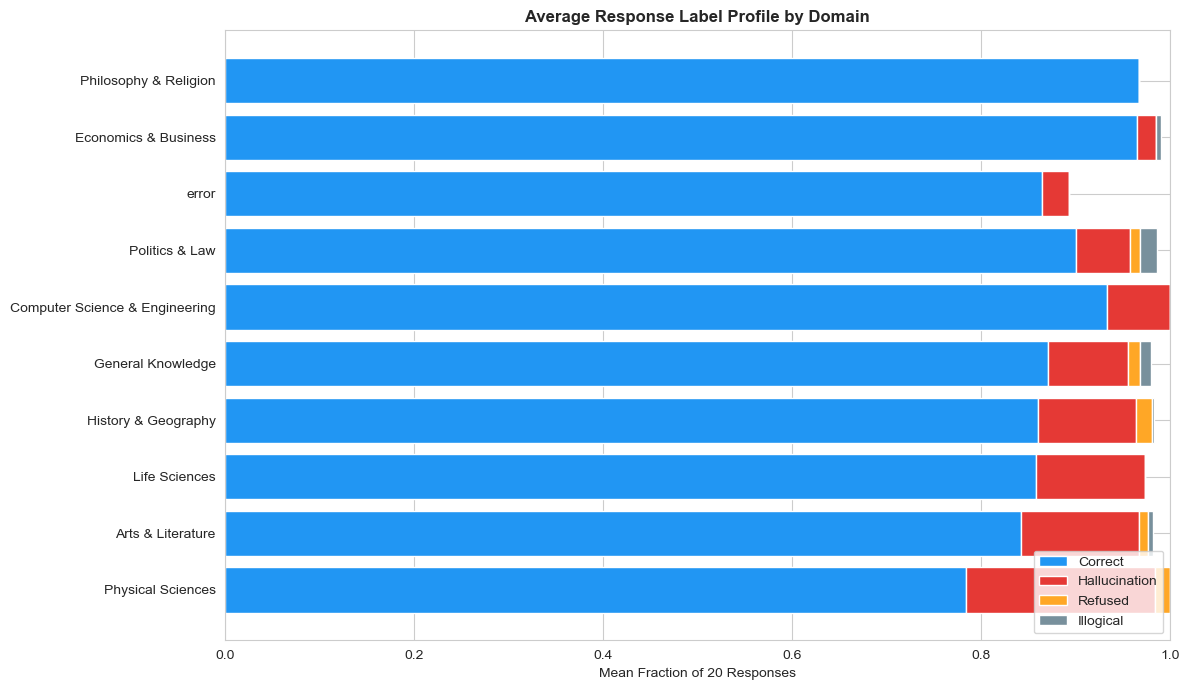

In [14]:
# stacked bar of label fractions per domain

if HAS_DOMAINS:
    fig, ax = plt.subplots(figsize=(12, max(4, len(domains_list) * 0.6 + 1)))
    frac_labels = ['frac_correct', 'frac_hallu', 'frac_refused', 'frac_illogical']
    frac_nice = ['Correct', 'Hallucination', 'Refused', 'Illogical']
    frac_colors = [LABEL_COLORS['correct'], LABEL_COLORS['hallucination'],
                   LABEL_COLORS['refused'], LABEL_COLORS['illogical']]

    df_plot = domain_fracs.reset_index()
    bottom = np.zeros(len(df_plot))
    for col, nice, color in zip(frac_labels, frac_nice, frac_colors):
        vals = df_plot[col].values
        ax.barh(df_plot['domain'], vals, left=bottom, color=color, label=nice)
        bottom += vals
    ax.set_xlabel('Mean Fraction of 20 Responses')
    ax.set_title('Average Response Label Profile by Domain', fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim(0, 1)
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig03_question_label_profiles.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
# naive vs strict hallucination rate

if HAS_DOMAINS:
    rate_compare = feat_df.groupby('domain').agg(
        naive_rate=('hall_rate_naive', 'mean'),
        strict_rate=('hall_rate_strict', 'mean'),
        mean_refused=('frac_refused', 'mean'),
        mean_illogical=('frac_illogical', 'mean'),
    ).sort_values('naive_rate', ascending=False)
    rate_compare['gap'] = rate_compare['naive_rate'] - rate_compare['strict_rate']
    print('Naive vs strict hallucination rate (gap = inflation from refused+illogical):')
    display(rate_compare.round(3))
else:
    naive_mean = feat_df['hall_rate_naive'].mean()
    strict_mean = feat_df['hall_rate_strict'].mean()
    print(f'Naive rate: {naive_mean:.3f}, Strict rate: {strict_mean:.3f}, Gap: {naive_mean - strict_mean:.3f}')

Naive vs strict hallucination rate (gap = inflation from refused+illogical):


,naive_rate,strict_rate,mean_refused,mean_illogical,gap
domain,,,,,
Physical Sciences,0.217,0.211,0.017,0.000,0.006
Arts & Literature,0.158,0.135,0.010,0.005,0.023
Life Sciences,0.142,0.117,0.000,0.000,0.025
History & Geography,0.140,0.116,0.017,0.002,0.024
error,0.136,0.030,0.000,0.000,0.106
General Knowledge,0.129,0.098,0.013,0.012,0.032
Politics & Law,0.100,0.063,0.011,0.018,0.037
Computer Science & Engineering,0.067,0.067,0.000,0.000,0.000
Economics & Business,0.035,0.021,0.000,0.005,0.014


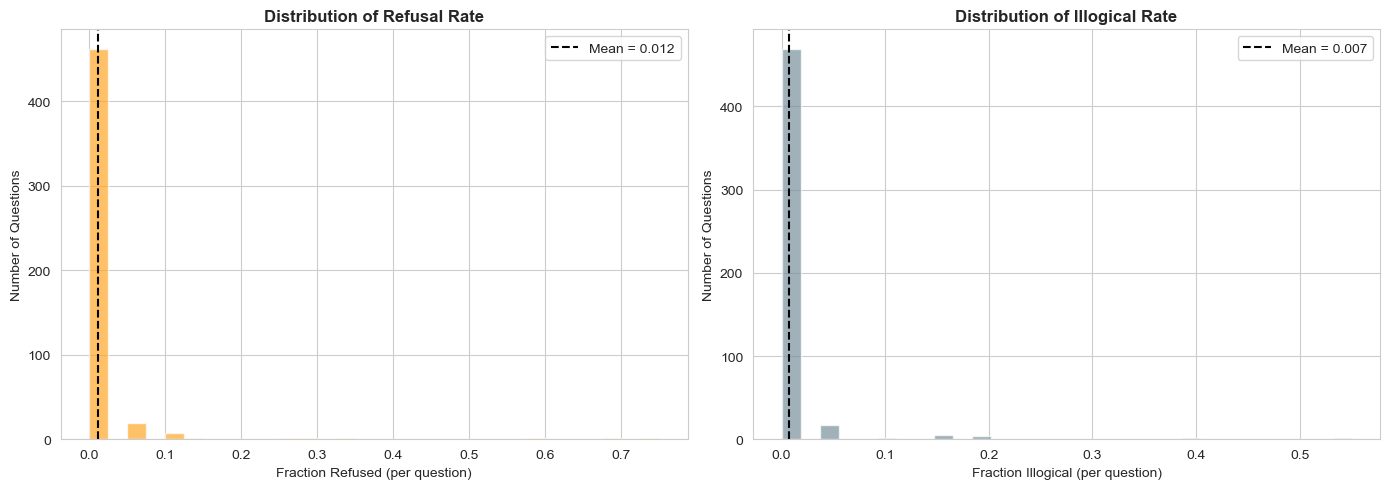

In [16]:
# distribution of refusal and illogical rates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(feat_df['frac_refused'], bins=30, color=LABEL_COLORS['refused'],
             alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Fraction Refused (per question)')
axes[0].set_ylabel('Number of Questions')
axes[0].set_title('Distribution of Refusal Rate', fontweight='bold')
axes[0].axvline(feat_df['frac_refused'].mean(), color='black', linestyle='--',
                label=f'Mean = {feat_df["frac_refused"].mean():.3f}')
axes[0].legend()

axes[1].hist(feat_df['frac_illogical'], bins=30, color=LABEL_COLORS['illogical'],
             alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Fraction Illogical (per question)')
axes[1].set_ylabel('Number of Questions')
axes[1].set_title('Distribution of Illogical Rate', fontweight='bold')
axes[1].axvline(feat_df['frac_illogical'].mean(), color='black', linestyle='--',
                label=f'Mean = {feat_df["frac_illogical"].mean():.3f}')
axes[1].legend()

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_refused_illogical_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

## Geometric Feature Distributions

In [17]:
for lab, tag in [(0, 'Correct'), (1, 'Hallucinated')]:
    sub = feat_df[feat_df['label'] == lab]
    print(f'--- {tag} (n={len(sub)}) ---')
    print(sub[GEO_FEATURES].describe().round(4).to_string())
    print()

--- Correct (n=457) ---
          H_sem     D_cos     M_bar         K    sig2_S
count  457.0000  457.0000  457.0000  457.0000  457.0000
mean     0.6759    0.0614   18.5361    2.8337    0.0289
std      0.8299    0.0786    4.1221    2.5527    0.0399
min     -0.0000   -0.0000    8.5771    1.0000    0.0000
25%     -0.0000    0.0030   16.5132    1.0000    0.0001
50%      0.2864    0.0273   18.0127    2.0000    0.0094
75%      1.1219    0.0921   20.2700    4.0000    0.0484
max      3.9219    0.4677   45.1209   17.0000    0.2258

--- Hallucinated (n=42) ---
         H_sem    D_cos    M_bar        K   sig2_S
count  42.0000  42.0000  42.0000  42.0000  42.0000
mean    2.0554   0.2061  27.4586   7.2143   0.0679
std     1.0882   0.1252   8.3003   4.4422   0.0337
min    -0.0000   0.0064   9.5123   1.0000   0.0002
25%     1.1647   0.1063  23.9024   4.0000   0.0472
50%     1.9262   0.1817  27.3624   6.0000   0.0622
75%     2.8693   0.2625  33.2797   8.7500   0.0906
max     4.1219   0.4756  43.1744  1

In [18]:
# hallucination rate summary

if HAS_DOMAINS:
    domain_stats = (
        feat_df.groupby('domain')
        .agg(
            n_questions=('label', 'count'),
            n_hallucinated=('label', 'sum'),
            hall_rate_mean=('hall_rate_strict', 'mean'),
            hall_rate_std=('hall_rate_strict', 'std'),
            mean_entropy=('H_sem', 'mean'),
            mean_refused=('frac_refused', 'mean'),
            mean_illogical=('frac_illogical', 'mean'),
        )
        .sort_values('hall_rate_mean', ascending=False)
    )
    domain_stats['pct_hallucinated'] = (
        domain_stats['n_hallucinated'] / domain_stats['n_questions'] * 100
    ).round(1)
    display(domain_stats.round(3))
    domain_stats.to_csv(os.path.join(OUTPUT_DIR, 'domain_stats.csv'))
else:
    print(f'Overall strict hall rate: {feat_df["hall_rate_strict"].mean():.3f}')
    print(f'Overall entropy: {feat_df["H_sem"].mean():.3f}')

,n_questions,n_hallucinated,hall_rate_mean,hall_rate_std,mean_entropy,mean_refused,mean_illogical,pct_hallucinated
domain,,,,,,,,
Physical Sciences,3,1,0.211,0.365,1.307,0.017,0.000,33.3
Arts & Literature,147,14,0.135,0.247,0.835,0.010,0.005,9.5
Life Sciences,13,1,0.117,0.272,1.305,0.000,0.000,7.7
History & Geography,105,9,0.116,0.246,0.780,0.017,0.002,8.6
General Knowledge,186,17,0.098,0.229,0.722,0.013,0.012,9.1
Computer Science & Engineering,3,0,0.067,0.076,0.574,0.000,0.000,0.0
Politics & Law,22,0,0.063,0.099,1.045,0.011,0.018,0.0
error,7,0,0.030,0.080,0.389,0.000,0.000,0.0
Economics & Business,10,0,0.021,0.038,0.669,0.000,0.005,0.0


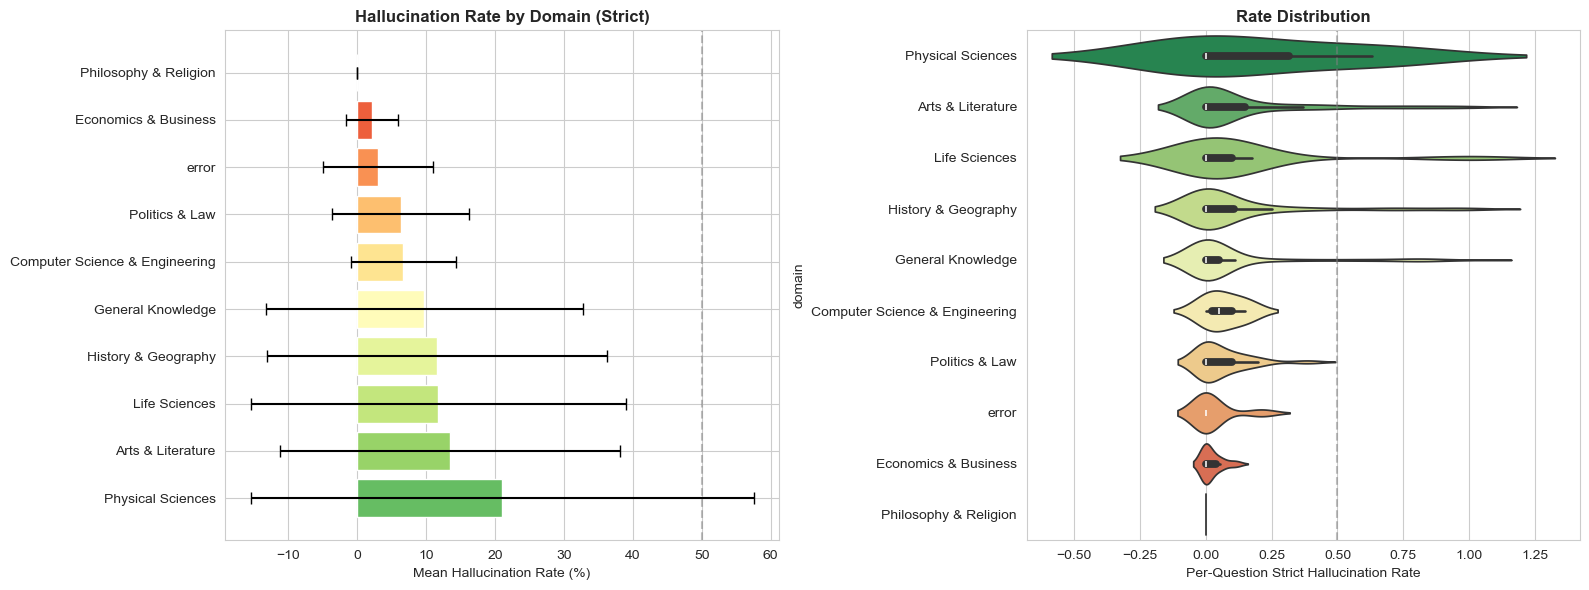

In [19]:
# hallucination rate bar + violin (if domains exist)

if HAS_DOMAINS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ds = domain_stats.reset_index()
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(ds)))
    axes[0].barh(ds['domain'], ds['hall_rate_mean'] * 100,
                 xerr=ds['hall_rate_std'] * 100,
                 color=colors, capsize=4)
    axes[0].set_xlabel('Mean Hallucination Rate (%)')
    axes[0].set_title('Hallucination Rate by Domain (Strict)', fontweight='bold')
    axes[0].axvline(50, color='gray', linestyle='--', alpha=0.5)

    order = ds['domain'].tolist()
    sns.violinplot(data=feat_df, y='domain', x='hall_rate_strict',
                   order=order, orient='h', palette='RdYlGn_r',
                   ax=axes[1], inner='box')
    axes[1].set_xlabel('Per-Question Strict Hallucination Rate')
    axes[1].set_title('Rate Distribution', fontweight='bold')
    axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig05_hallu_rate_by_domain.png'), dpi=150, bbox_inches='tight')
    plt.show()

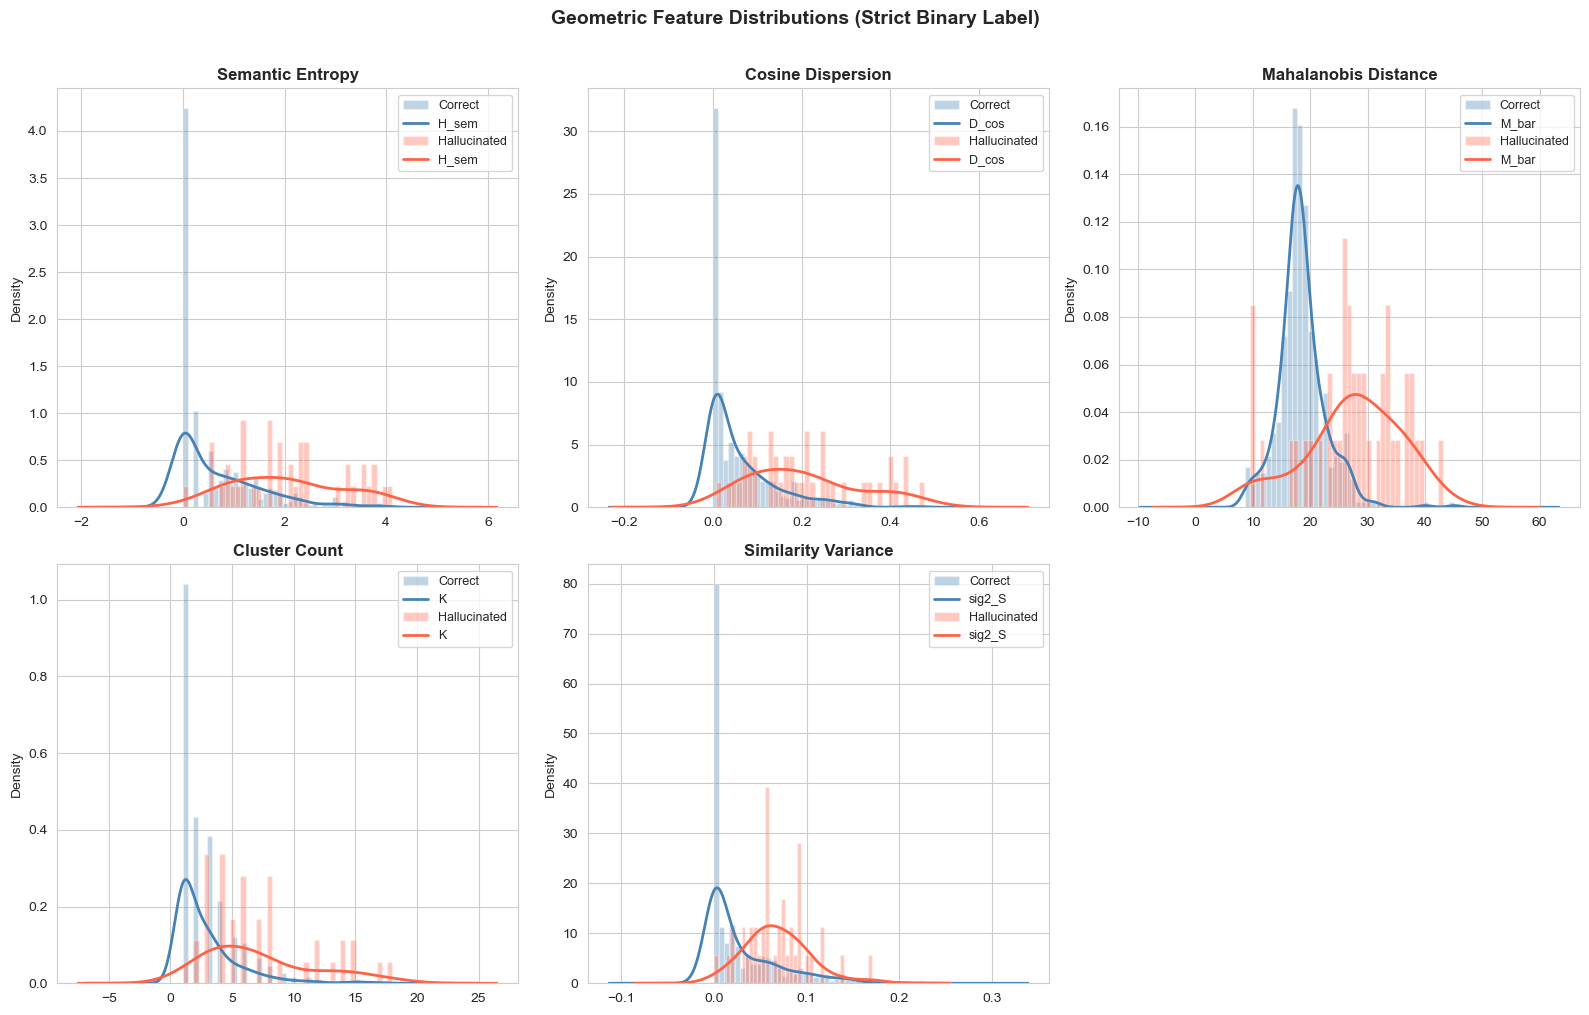

In [20]:
# KDE plots for each feature

FEAT_LABELS = {
    'H_sem':  'Semantic Entropy',
    'D_cos':  'Cosine Dispersion',
    'M_bar':  'Mahalanobis Distance',
    'K':      'Cluster Count',
    'sig2_S': 'Similarity Variance',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (feat, nice) in enumerate(FEAT_LABELS.items()):
    ax = axes[i]
    for lab, color, lbl in [(0, 'steelblue', 'Correct'), (1, 'tomato', 'Hallucinated')]:
        vals = feat_df.loc[feat_df['label'] == lab, feat]
        ax.hist(vals, bins=40, alpha=0.35, color=color, density=True, label=lbl)
        if len(vals) > 2:
            try:
                vals.plot.kde(ax=ax, color=color, linewidth=2)
            except Exception:
                pass
    ax.set_title(nice, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Geometric Feature Distributions (Strict Binary Label)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig06_kde_features.png'), dpi=150, bbox_inches='tight')
plt.show()

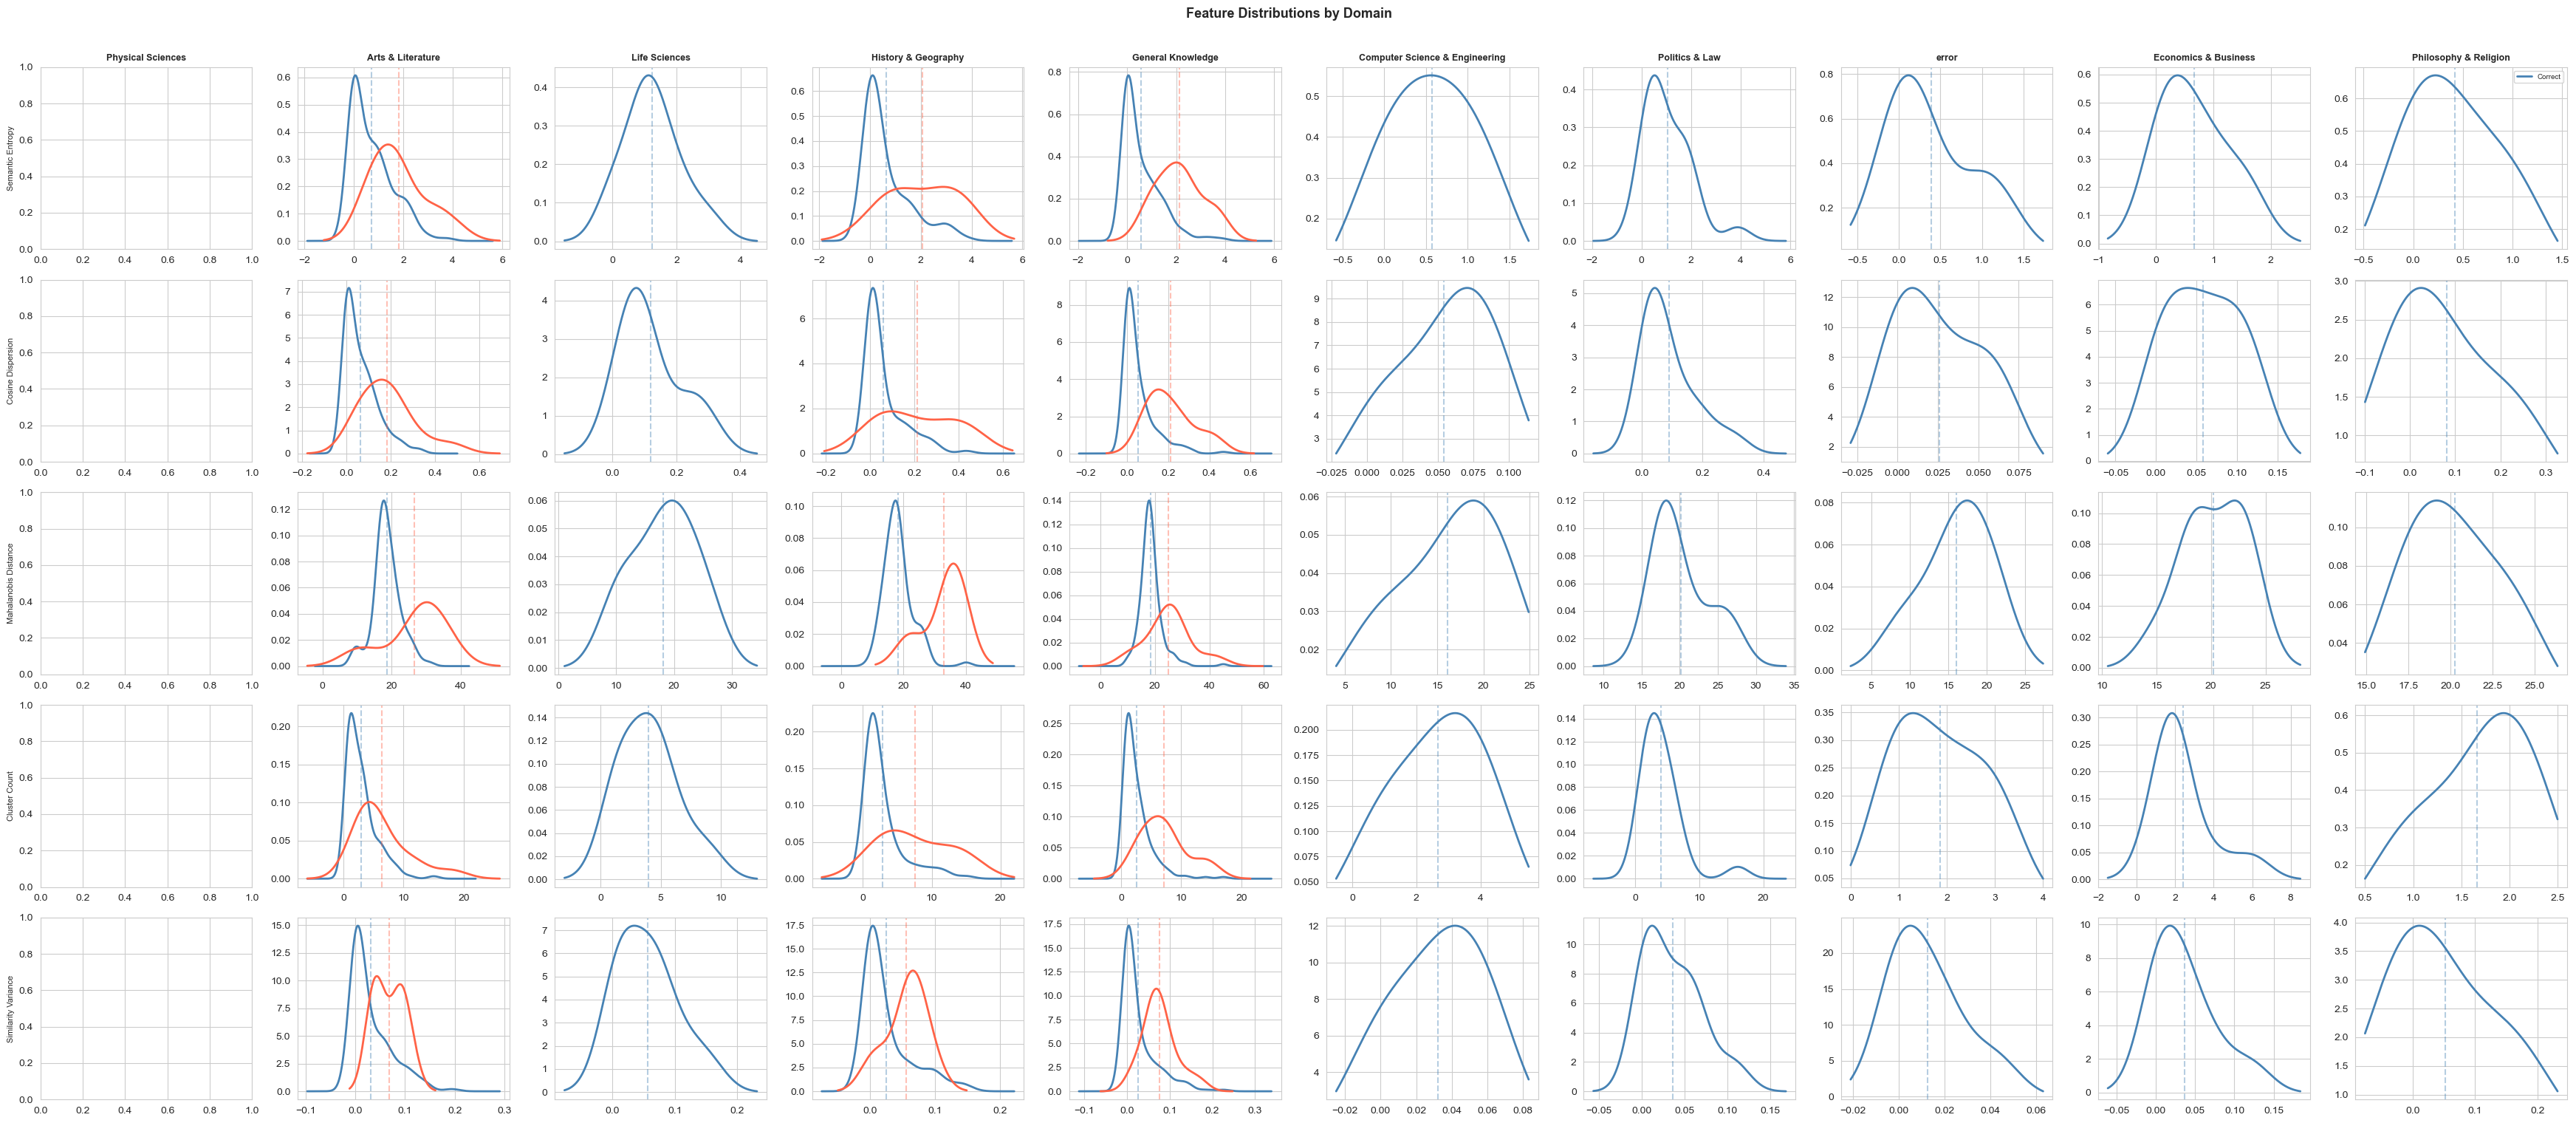

In [21]:
# per-domain feature KDEs (if multiple domains)

if HAS_DOMAINS:
    domains_ordered = domain_stats.reset_index()['domain'].tolist()
    n_domains = len(domains_ordered)

    fig, axes = plt.subplots(
        len(FEAT_LABELS), n_domains,
        figsize=(3.5 * n_domains, 3 * len(FEAT_LABELS)),
        sharey=False
    )
    if n_domains == 1:
        axes = axes.reshape(-1, 1)

    for row, (feat, nice) in enumerate(FEAT_LABELS.items()):
        for col, dom in enumerate(domains_ordered):
            ax = axes[row][col]
            sub = feat_df[feat_df['domain'] == dom]
            for lab, color, name in [(0, 'steelblue', 'Correct'), (1, 'tomato', 'Hallucinated')]:
                vals = sub[sub['label'] == lab][feat]
                if len(vals) > 2:
                    try:
                        vals.plot.kde(ax=ax, color=color, label=name, linewidth=2)
                    except Exception:
                        pass
                    ax.axvline(vals.mean(), color=color, linestyle='--', alpha=0.4)
            if row == 0:
                ax.set_title(dom, fontweight='bold', fontsize=9)
            ax.set_ylabel(nice if col == 0 else '', fontsize=8)
            ax.set_xlabel('')
            if row == 0 and col == n_domains - 1:
                ax.legend(fontsize=7)

    plt.suptitle('Feature Distributions by Domain', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_kde_by_domain.png'), dpi=120, bbox_inches='tight')
    plt.show()

### Correlation and Heatmaps

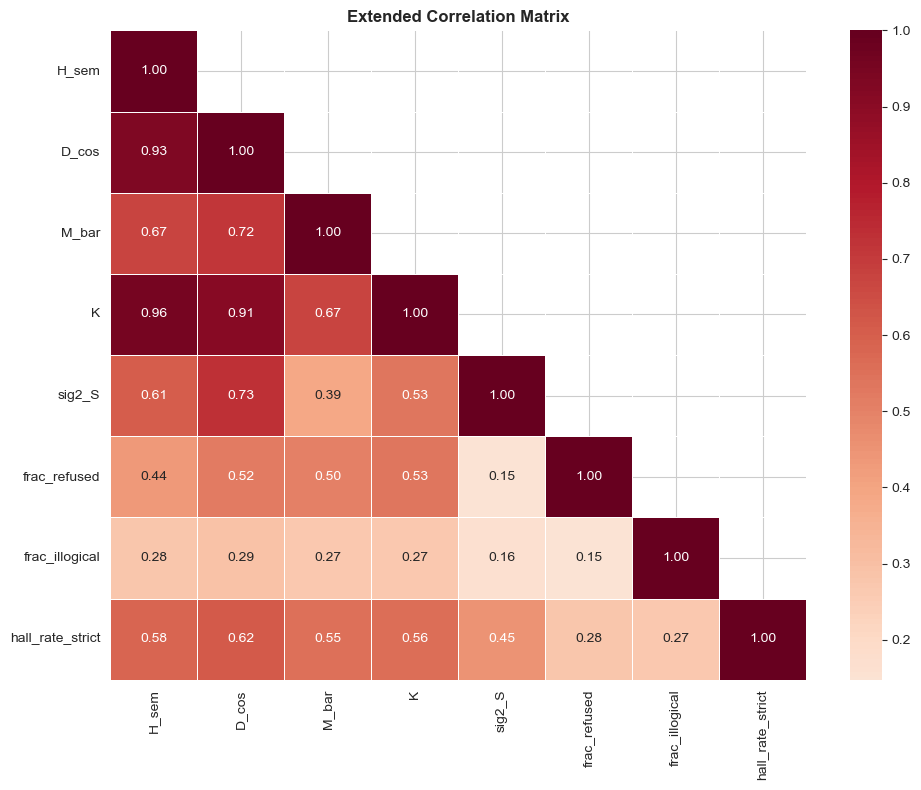

In [22]:
corr_cols = GEO_FEATURES + ['frac_refused', 'frac_illogical', 'hall_rate_strict']
corr = feat_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, mask=mask, linewidths=0.5)
ax.set_title('Extended Correlation Matrix', fontweight='bold')
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

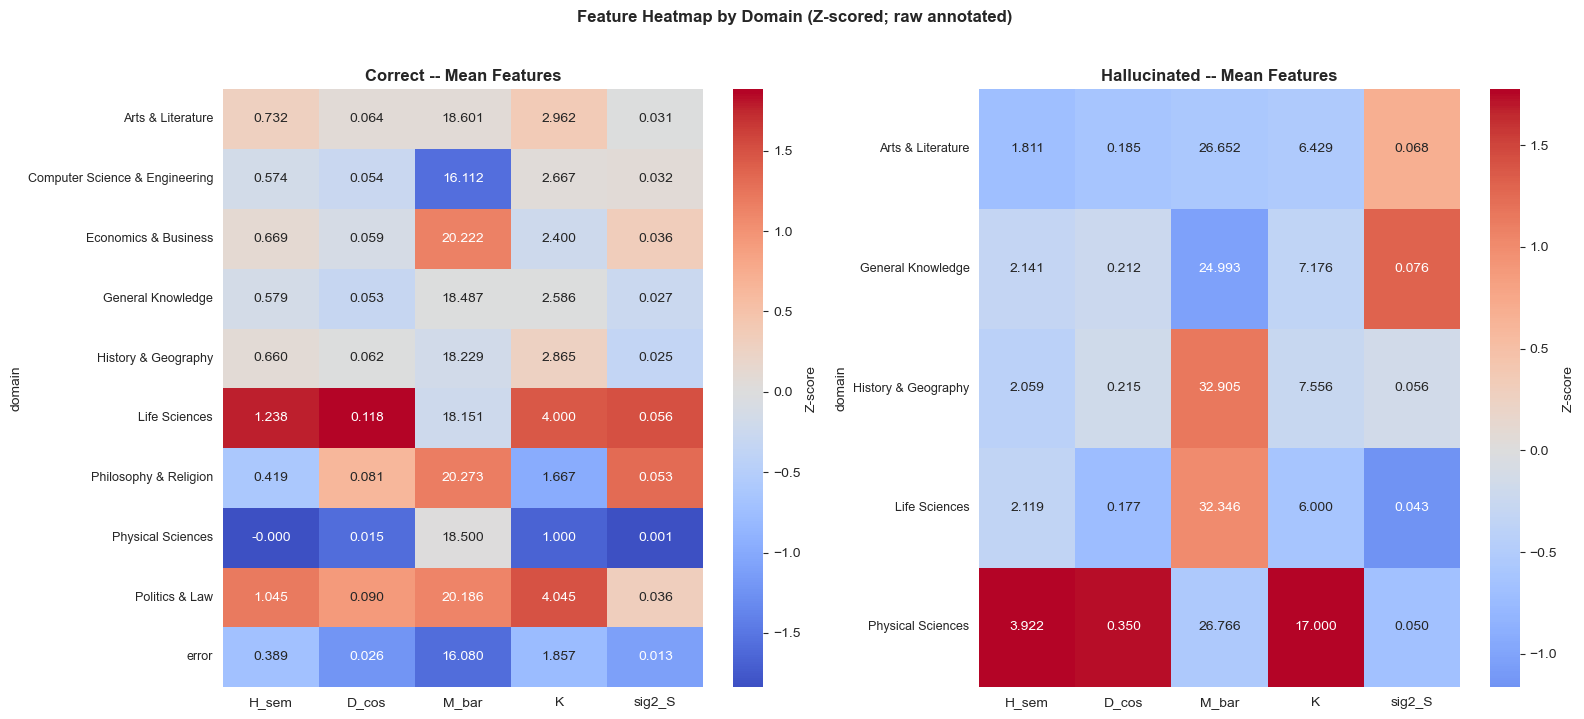

In [23]:
# z-scored feature heatmaps by domain

if HAS_DOMAINS:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(domains_list) * 0.6 + 1)))
    for ax_idx, (lbl_val, split_name) in enumerate([(0, 'Correct'), (1, 'Hallucinated')]):
        hm_data = feat_df[feat_df['label'] == lbl_val].groupby('domain')[GEO_FEATURES].mean()
        hm_norm = (hm_data - hm_data.mean()) / (hm_data.std() + 1e-9)
        sns.heatmap(hm_norm, annot=hm_data.round(3), fmt='.3f',
                    cmap='coolwarm', center=0, ax=axes[ax_idx],
                    cbar_kws={'label': 'Z-score'})
        axes[ax_idx].set_title(f'{split_name} -- Mean Features', fontweight='bold')
        axes[ax_idx].tick_params(axis='y', labelsize=9)
    plt.suptitle('Feature Heatmap by Domain (Z-scored; raw annotated)',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_domain_heatmaps.png'), dpi=150, bbox_inches='tight')
    plt.show()

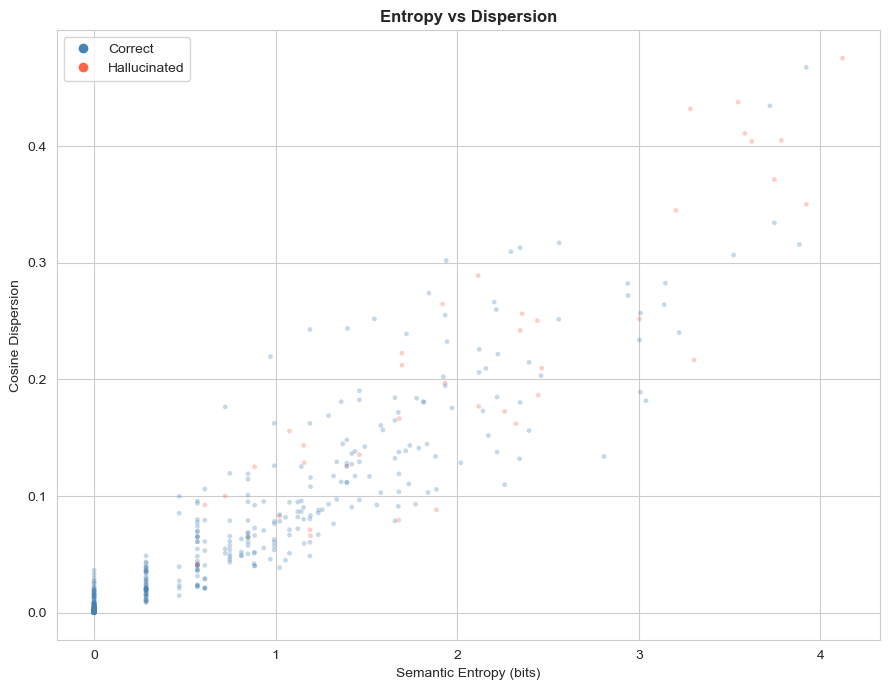

In [24]:
# scatter + pairplot

fig, ax = plt.subplots(figsize=(9, 7))
colors = feat_df['label'].map({0: 'steelblue', 1: 'tomato'})
ax.scatter(feat_df['H_sem'], feat_df['D_cos'], c=colors, alpha=0.3, s=12, edgecolors='none')
ax.set_xlabel('Semantic Entropy (bits)')
ax.set_ylabel('Cosine Dispersion')
ax.set_title('Entropy vs Dispersion', fontweight='bold')
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Correct'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=8, label='Hallucinated'),
]
ax.legend(handles=legend_elems)
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_entropy_vs_dispersion.png'), dpi=150, bbox_inches='tight')
plt.show()

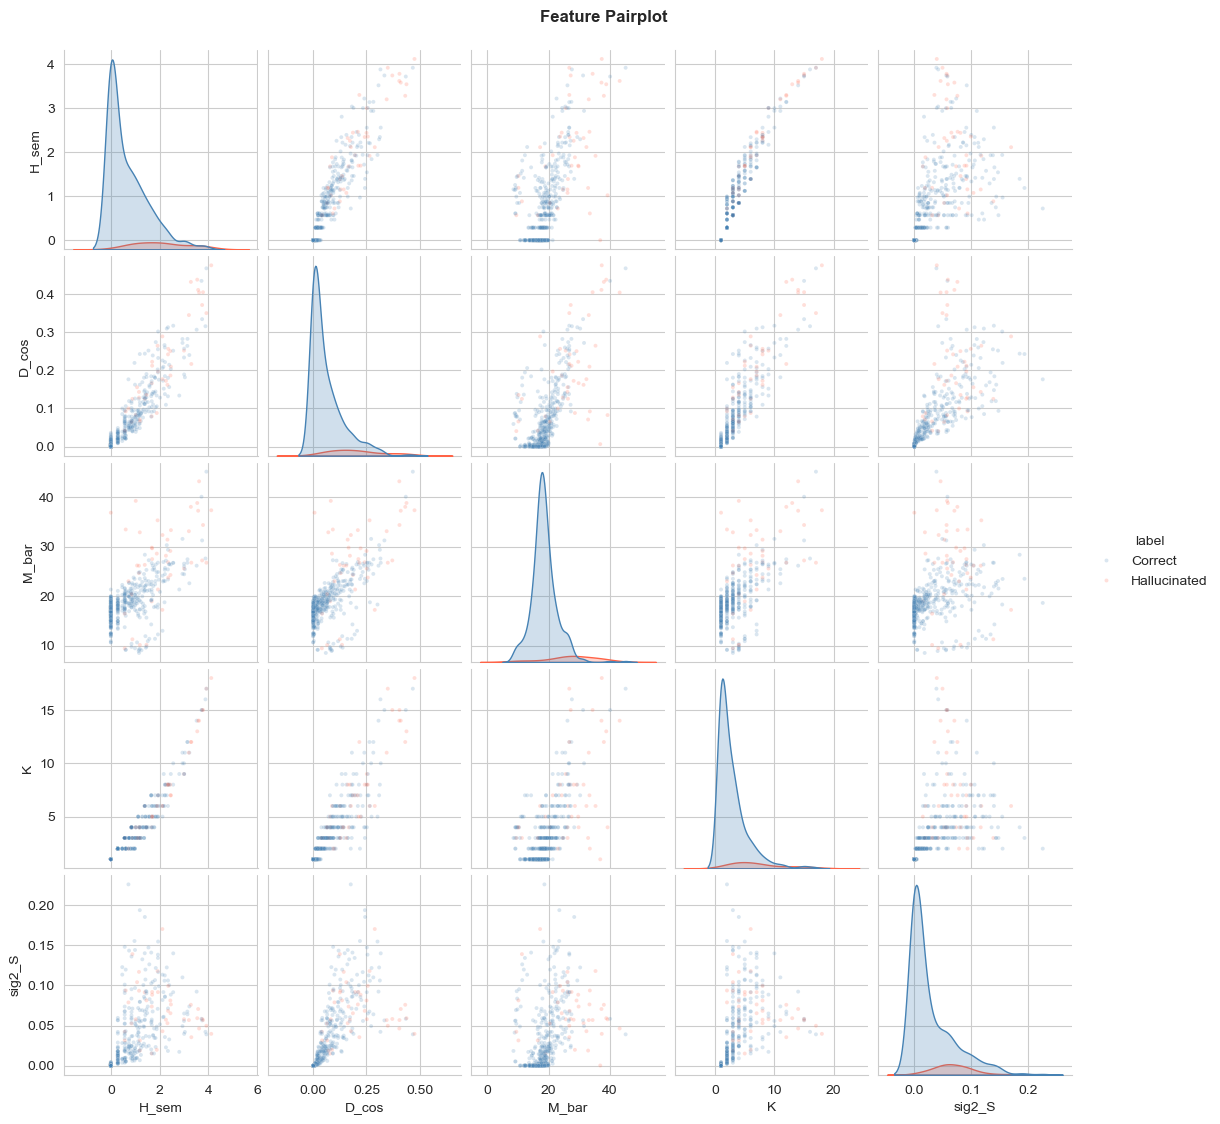

In [25]:
plot_df = feat_df[GEO_FEATURES + ['label']].copy()
plot_df['label'] = plot_df['label'].map({0: 'Correct', 1: 'Hallucinated'})
g = sns.pairplot(plot_df, hue='label',
                 palette={'Correct': 'steelblue', 'Hallucinated': 'tomato'},
                 diag_kind='kde', plot_kws={'alpha': 0.2, 's': 8}, height=2.2)
g.fig.suptitle('Feature Pairplot', y=1.02, fontweight='bold')
g.savefig(os.path.join(OUTPUT_DIR, 'fig11_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()

## Statistical Tests

In [26]:
# global KS tests
print('Global KS tests (Bonferroni alpha = 0.01):')
ks_global = []
for feat in GEO_FEATURES:
    g0 = feat_df.loc[feat_df['label'] == 0, feat].values
    g1 = feat_df.loc[feat_df['label'] == 1, feat].values
    if len(g0) < 2 or len(g1) < 2:
        continue
    stat, p = ks_2samp(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ks_global.append({'Feature': feat, 'KS_stat': stat, 'p_value': p, 'sig': sig})
    print(f'  {feat:10s}  D={stat:.4f}  p={p:.2e}  {sig}')

pd.DataFrame(ks_global).to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_global.csv'), index=False)

Global KS tests (Bonferroni alpha = 0.01):
  H_sem       D=0.5554  p=1.27e-11  ***
  D_cos       D=0.5916  p=2.97e-13  ***
  M_bar       D=0.6676  p=3.26e-17  ***
  K           D=0.5275  p=1.87e-10  ***
  sig2_S      D=0.5831  p=7.46e-13  ***


Tests: 50, Bonferroni alpha: 0.001000


,Domain,Feature,KS_stat,p_value,Significant
0,Arts & Literature,H_sem,0.4774,3.755595e-03,False
1,Arts & Literature,D_cos,0.5338,7.300534e-04,True
2,Arts & Literature,M_bar,0.7406,1.686484e-07,True
3,Arts & Literature,K,0.4398,9.908864e-03,False
4,Arts & Literature,sig2_S,0.6466,1.292559e-05,True
5,General Knowledge,H_sem,0.6812,1.484744e-07,True
6,General Knowledge,D_cos,0.7751,5.281337e-10,True
7,General Knowledge,M_bar,0.6230,2.602726e-06,True
8,General Knowledge,K,0.6046,6.571042e-06,True
9,General Knowledge,sig2_S,0.6634,3.887731e-07,True


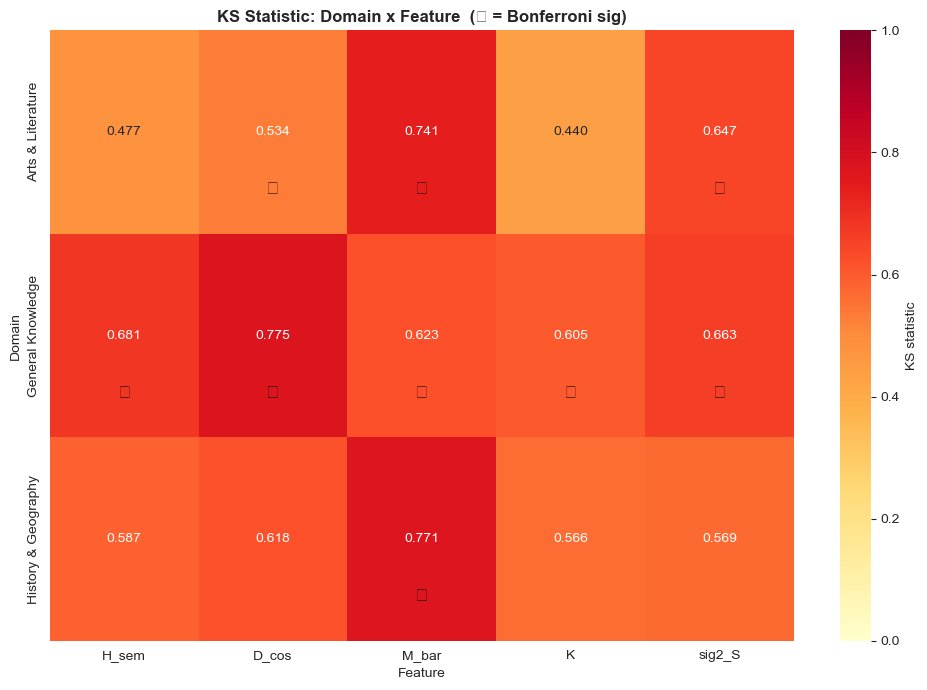

In [27]:
# per-domain KS tests + heatmap

if HAS_DOMAINS:
    n_tests = len(GEO_FEATURES) * len(domains_list)
    alpha_bonf = 0.05 / n_tests
    print(f'Tests: {n_tests}, Bonferroni alpha: {alpha_bonf:.6f}')

    ks_rows = []
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        for feat in GEO_FEATURES:
            g0 = df_d[df_d['label'] == 0][feat].values
            g1 = df_d[df_d['label'] == 1][feat].values
            if len(g0) < 2 or len(g1) < 2:
                continue
            stat, p = ks_2samp(g0, g1)
            ks_rows.append({'Domain': dom, 'Feature': feat,
                            'KS_stat': round(stat, 4), 'p_value': p,
                            'Significant': p < alpha_bonf})

    df_ks = pd.DataFrame(ks_rows)
    df_ks.to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_per_domain.csv'), index=False)
    display(df_ks)

    ks_pivot = df_ks.pivot(index='Domain', columns='Feature', values='KS_stat').fillna(0)
    sig_pivot = df_ks.pivot(index='Domain', columns='Feature', values='Significant').fillna(False)
    ks_pivot = ks_pivot.reindex(columns=GEO_FEATURES)
    sig_pivot = sig_pivot.reindex(columns=GEO_FEATURES)

    plt.figure(figsize=(10, max(4, len(domains_list) * 0.6 + 1)))
    ax = sns.heatmap(ks_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                     vmin=0, vmax=1, cbar_kws={'label': 'KS statistic'})
    for i, dom in enumerate(ks_pivot.index):
        for j, feat in enumerate(ks_pivot.columns):
            if sig_pivot.loc[dom, feat]:
                ax.text(j + 0.5, i + 0.78, '\u2605', ha='center', va='center',
                        color='black', fontsize=13)
    plt.title(f'KS Statistic: Domain x Feature  (\u2605 = Bonferroni sig)',
              fontweight='bold')
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_ks_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Permutation Test on Entropy Difference

Observed delta (hallu - correct): 1.3796 bits
Permutation p-value (10000 iters): 0.000000


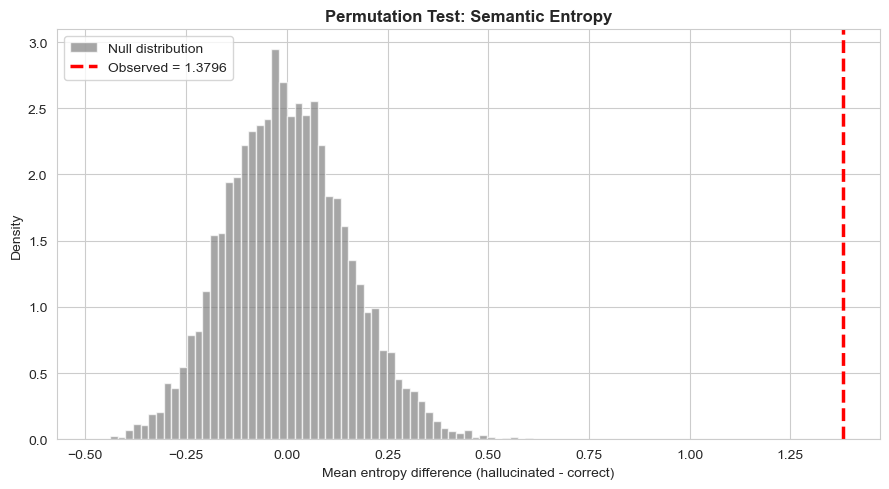

In [28]:
ent_correct = feat_df.loc[feat_df['label'] == 0, 'H_sem'].values
ent_hallu = feat_df.loc[feat_df['label'] == 1, 'H_sem'].values
delta_obs = ent_hallu.mean() - ent_correct.mean()
print(f'Observed delta (hallu - correct): {delta_obs:.4f} bits')

all_ent = feat_df['H_sem'].values
all_labels = feat_df['label'].values
rng = np.random.default_rng(RANDOM_SEED)

perm_deltas = np.zeros(N_PERMUTATIONS)
for p in range(N_PERMUTATIONS):
    shuffled = rng.permutation(all_labels)
    perm_deltas[p] = all_ent[shuffled == 1].mean() - all_ent[shuffled == 0].mean()

perm_pval = (perm_deltas >= delta_obs).sum() / N_PERMUTATIONS
print(f'Permutation p-value ({N_PERMUTATIONS} iters): {perm_pval:.6f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(perm_deltas, bins=60, color='gray', alpha=0.7, density=True, label='Null distribution')
ax.axvline(delta_obs, color='red', linewidth=2.5, linestyle='--',
           label=f'Observed = {delta_obs:.4f}')
ax.set_xlabel('Mean entropy difference (hallucinated - correct)')
ax.set_ylabel('Density')
ax.set_title('Permutation Test: Semantic Entropy', fontweight='bold')
ax.legend()
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()

## Classification and Ablation

In [29]:
EXTENDED_FEATURES = GEO_FEATURES + ['frac_refused', 'frac_illogical']

X_geo = feat_df[GEO_FEATURES].values
X_ext = feat_df[EXTENDED_FEATURES].values
y_all = feat_df['label'].values

scaler_geo = StandardScaler()
scaler_ext = StandardScaler()
X_geo_sc = scaler_geo.fit_transform(X_geo)
X_ext_sc = scaler_ext.fit_transform(X_ext)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
    ),
}

ablation_sets = {
    'Entropy only (H_sem)':        ('geo', [0]),
    'Geometry only (D_cos, M_bar)': ('geo', [1, 2]),
    'Entropy + Geometry':           ('geo', [0, 1, 2]),
    'All 5 geometric':              ('geo', [0, 1, 2, 3, 4]),
    'All 5 + refused + illogical':  ('ext', [0, 1, 2, 3, 4, 5, 6]),
}

clf_rows = []
for variant, (fset, feat_idx) in ablation_sets.items():
    X_use = X_geo_sc if fset == 'geo' else X_ext_sc
    X_sub = X_use[:, feat_idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        clf_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:35s} | {clf_name:22s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

df_clf = pd.DataFrame(clf_rows)
df_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False)
print()
display(df_clf.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))

  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.8531 +/- 0.0580
  Entropy only (H_sem)                | Random Forest          | AUC = 0.7132 +/- 0.1144
  Entropy only (H_sem)                | XGBoost                | AUC = 0.7535 +/- 0.0783
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.8498 +/- 0.0986
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.8944 +/- 0.0388
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.8611 +/- 0.0802
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.8431 +/- 0.0914
  Entropy + Geometry                  | Random Forest          | AUC = 0.8917 +/- 0.0481
  Entropy + Geometry                  | XGBoost                | AUC = 0.8514 +/- 0.0583
  All 5 geometric                     | Logistic Regression    | AUC = 0.8688 +/- 0.0860
  All 5 geometric                     | Random Forest          | AUC = 0.9052 +/- 0.0127
  All 5 geometric    

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 + refused + illogical,0.847,0.917,0.865
All 5 geometric,0.869,0.905,0.863
Entropy + Geometry,0.843,0.892,0.851
Entropy only (H_sem),0.853,0.713,0.754
"Geometry only (D_cos, M_bar)",0.850,0.894,0.861


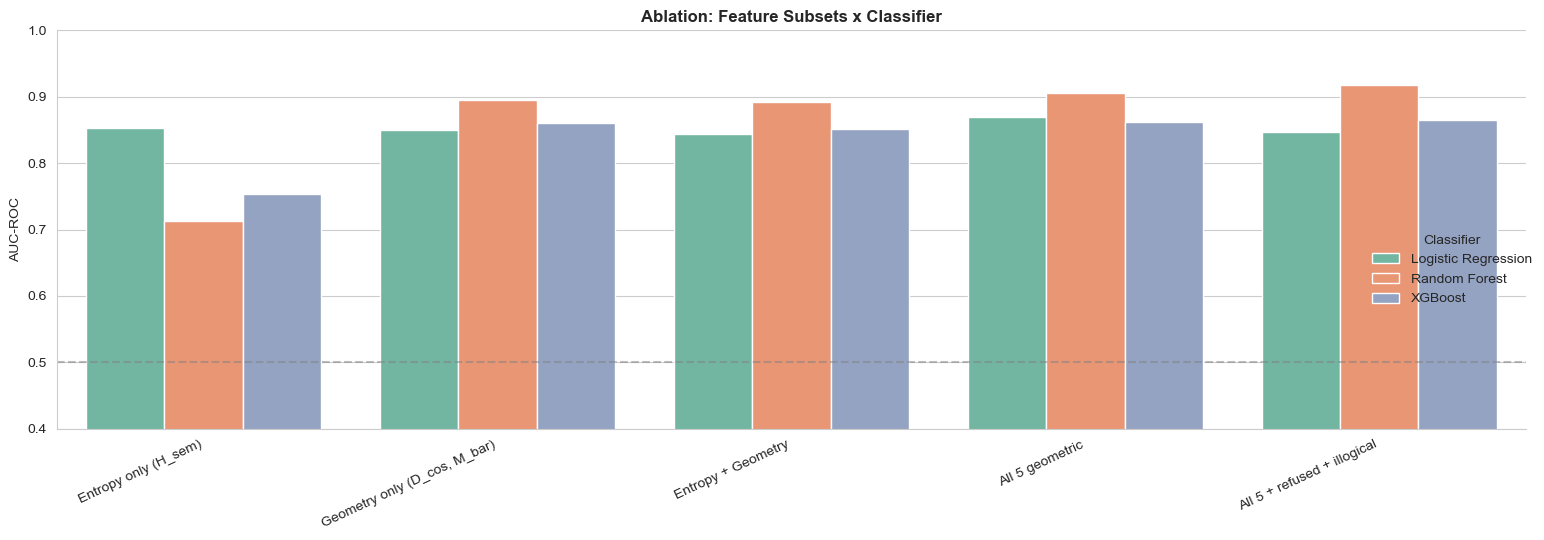

In [30]:
g = sns.catplot(
    data=df_clf, kind='bar',
    x='Variant', y='AUC_mean', hue='Classifier',
    palette='Set2', height=5.5, aspect=2.5,
    capsize=0.05, errwidth=1.5,
)
g.ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
g.ax.set_ylim(0.4, 1.0)
g.ax.set_title('Ablation: Feature Subsets x Classifier', fontweight='bold')
g.ax.set_ylabel('AUC-ROC')
g.ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

### Per-Domain Classification

  Skipping Computer Science & Engineering
  Skipping Economics & Business
  Skipping Philosophy & Religion
  Skipping Physical Sciences
  Skipping Politics & Law
  Skipping error


Classifier,Logistic Regression,Random Forest,XGBoost
Domain,,,
Arts & Literature,0.772,0.971,0.914
General Knowledge,0.898,0.884,0.841
History & Geography,0.937,0.951,0.842


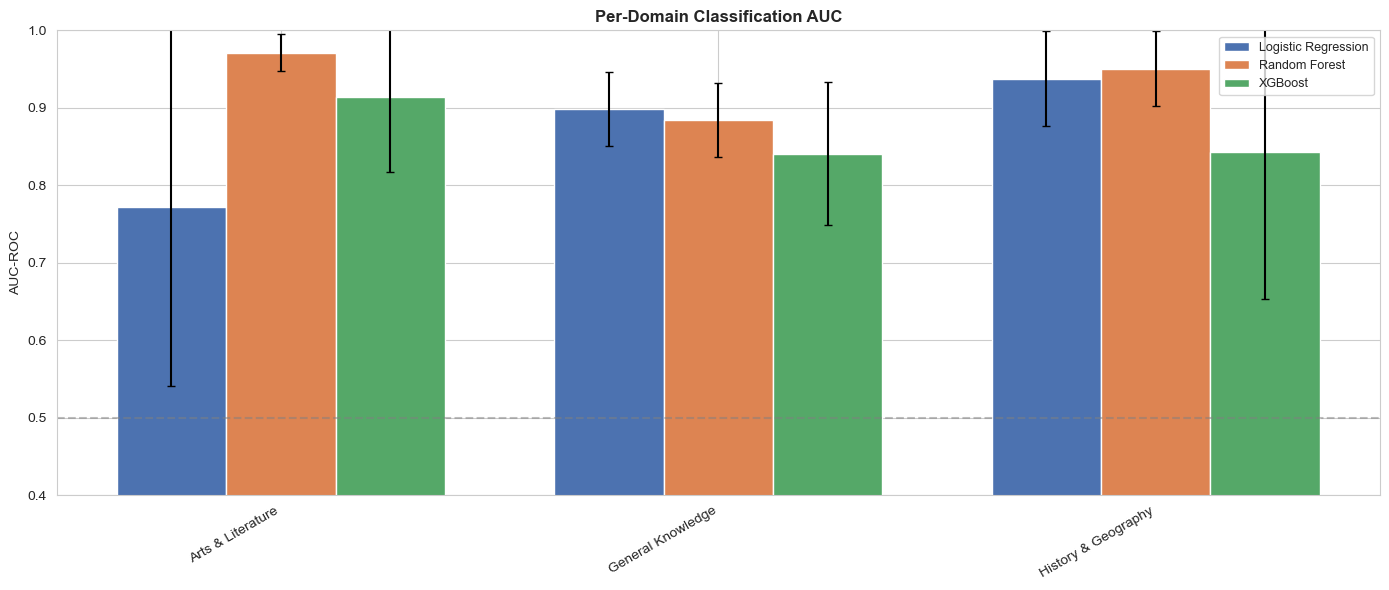

In [31]:
if HAS_DOMAINS:
    domain_clf_rows = []
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = df_d[GEO_FEATURES].values
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2 or len(y_d) < 10:
            print(f'  Skipping {dom}')
            continue
        X_d_sc = StandardScaler().fit_transform(X_d)
        for clf_name, clf in classifiers.items():
            n_folds = min(5, min(Counter(y_d).values()))
            if n_folds < 2:
                continue
            cv_d = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
            scores = cross_val_score(clf, X_d_sc, y_d, cv=cv_d, scoring='roc_auc')
            domain_clf_rows.append({
                'Domain': dom, 'Classifier': clf_name,
                'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
            })

    df_dom_clf = pd.DataFrame(domain_clf_rows)
    df_dom_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_per_domain.csv'), index=False)
    display(df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean').round(3))

    # bar chart
    pivot_dom = df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean')
    dom_list = pivot_dom.index.tolist()
    x_pos = np.arange(len(dom_list))
    width = 0.25
    clf_names = list(classifiers.keys())
    colors_clf = ['#4C72B0', '#DD8452', '#55A868']

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (cname, color) in enumerate(zip(clf_names, colors_clf)):
        sub = df_dom_clf[df_dom_clf['Classifier'] == cname].set_index('Domain')
        aucs = sub.reindex(dom_list)['AUC_mean'].fillna(0)
        stds = sub.reindex(dom_list)['AUC_std'].fillna(0)
        ax.bar(x_pos + i * width, aucs, width, label=cname,
               color=color, yerr=stds, capsize=3)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(dom_list, rotation=30, ha='right')
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('Per-Domain Classification AUC', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_domain_classification.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Bootstrap AUC Confidence Intervals

In [32]:
rng_boot = np.random.default_rng(RANDOM_SEED)

# global bootstrap
print('Global bootstrap (RF, 5 geometric features):')
auc_boot_global = []
for _ in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(y_all), len(y_all), replace=True)
    oob = np.setdiff1d(np.arange(len(y_all)), idx)
    if len(oob) < 10 or len(np.unique(y_all[oob])) < 2:
        continue
    rf_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
    rf_b.fit(X_geo_sc[idx], y_all[idx])
    proba = rf_b.predict_proba(X_geo_sc[oob])[:, 1]
    auc_boot_global.append(roc_auc_score(y_all[oob], proba))

auc_boot_global = np.array(auc_boot_global)
ci_lo, ci_hi = np.percentile(auc_boot_global, [2.5, 97.5])
print(f'  AUC = {auc_boot_global.mean():.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()

# per-domain bootstrap
boot_rows = []
if HAS_DOMAINS:
    print('Per-domain bootstrap:')
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            continue
        auc_list = []
        for _ in range(N_BOOTSTRAP):
            idx = rng_boot.choice(len(y_d), len(y_d), replace=True)
            oob = np.setdiff1d(np.arange(len(y_d)), idx)
            if len(oob) < 5 or len(np.unique(y_d[oob])) < 2:
                continue
            rf_b = RandomForestClassifier(n_estimators=50, random_state=0)
            rf_b.fit(X_d[idx], y_d[idx])
            proba = rf_b.predict_proba(X_d[oob])[:, 1]
            auc_list.append(roc_auc_score(y_d[oob], proba))
        if len(auc_list) < 10:
            continue
        arr = np.array(auc_list)
        lo, hi = np.percentile(arr, [2.5, 97.5])
        boot_rows.append({'Domain': dom, 'AUC_mean': arr.mean(), 'CI_low': lo, 'CI_high': hi})
        print(f'  {dom:30s}  AUC={arr.mean():.3f}  [{lo:.3f}, {hi:.3f}]')

df_boot = pd.DataFrame(boot_rows).sort_values('AUC_mean', ascending=True) if boot_rows else pd.DataFrame()
if len(df_boot) > 0:
    df_boot.to_csv(os.path.join(OUTPUT_DIR, 'bootstrap_auc.csv'), index=False)

Global bootstrap (RF, 5 geometric features):
  AUC = 0.8943  95% CI [0.8275, 0.9486]

Per-domain bootstrap:
  Arts & Literature               AUC=0.919  [0.692, 0.997]
  General Knowledge               AUC=0.862  [0.709, 0.961]
  History & Geography             AUC=0.900  [0.664, 1.000]


IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(auc_boot_global, bins=50, color='#1565C0', alpha=0.7, density=True)
axes[0].axvline(ci_lo, color='red', linestyle='--', label=f'2.5%={ci_lo:.3f}')
axes[0].axvline(ci_hi, color='red', linestyle='--', label=f'97.5%={ci_hi:.3f}')
axes[0].axvline(auc_boot_global.mean(), color='black', linewidth=2,
                label=f'Mean={auc_boot_global.mean():.3f}')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_ylabel('Density')
axes[0].set_title('Bootstrap AUC (Global)', fontweight='bold')
axes[0].legend(fontsize=9)

if len(df_boot) > 0:
    y_pos = np.arange(len(df_boot))
    axes[1].barh(y_pos, df_boot['AUC_mean'],
                 xerr=[df_boot['AUC_mean'] - df_boot['CI_low'],
                       df_boot['CI_high'] - df_boot['AUC_mean']],
                 capsize=5, color='steelblue', alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(df_boot['Domain'])
    axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('AUC-ROC')
    axes[1].set_title('Per-Domain Bootstrap AUC with 95% CI', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Single domain -- see global bootstrap',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig16_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves

In [ ]:
# individual features vs combined

fig, ax = plt.subplots(figsize=(9, 7))
feat_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, (feat, color) in enumerate(zip(GEO_FEATURES, feat_colors)):
    vals = X_geo_sc[:, i]
    fpr, tpr, _ = roc_curve(y_all, vals)
    auc_s = roc_auc_score(y_all, vals)
    ax.plot(fpr, tpr, color=color, linewidth=1.5, alpha=0.8,
            label=f'{feat} (AUC={auc_s:.3f})')

rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
rf_full.fit(X_geo_sc, y_all)
y_scores = rf_full.predict_proba(X_geo_sc)[:, 1]
fpr_a, tpr_a, _ = roc_curve(y_all, y_scores)
auc_a = roc_auc_score(y_all, y_scores)
ax.plot(fpr_a, tpr_a, color='black', linewidth=2.5,
        label=f'All 5 - RF (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Individual Features vs Combined', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig17_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# per-domain ROC

if HAS_DOMAINS:
    fig, ax = plt.subplots(figsize=(9, 7))
    roc_colors = plt.cm.tab10(np.linspace(0, 1, len(domains_list)))
    for color, dom in zip(roc_colors, domains_list):
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            continue
        rf_d = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
        rf_d.fit(X_d, y_d)
        proba = rf_d.predict_proba(X_d)[:, 1]
        fpr, tpr, _ = roc_curve(y_d, proba)
        auc_val = roc_auc_score(y_d, proba)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{dom} ({auc_val:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC - RF Per Domain', fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig18_roc_domains.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Feature Importance

In [ ]:
xgb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
)

if HAS_DOMAINS:
    importance_data = {}
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            importance_data[dom] = np.zeros(5)
            continue
        xgb_imp.fit(X_d, y_d)
        booster = xgb_imp.get_booster()
        gain_dict = booster.get_score(importance_type='gain')
        gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
        total = gains.sum()
        importance_data[dom] = gains / total if total > 0 else gains

    df_imp = pd.DataFrame(importance_data, index=GEO_FEATURES).T
    print('Normalized GAIN importance per domain:')
    display(df_imp.round(3))
else:
    # single domain: just global importance
    xgb_imp.fit(X_geo_sc, y_all)
    booster = xgb_imp.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
    total = gains.sum()
    gains_norm = gains / total if total > 0 else gains
    df_imp = pd.DataFrame({'Feature': GEO_FEATURES, 'Gain': gains_norm})
    display(df_imp.round(3))

In [ ]:
feat_colors_list = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

if HAS_DOMAINS and isinstance(df_imp.index[0], str) and df_imp.shape[1] == 5:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(domains_list) * 0.6 + 1)))

    sns.heatmap(df_imp, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=df_imp.values.max(),
                ax=axes[0], linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Normalized Gain'})
    axes[0].set_title('XGBoost GAIN per Domain', fontweight='bold')

    bottoms = np.zeros(len(df_imp))
    for feat, color in zip(GEO_FEATURES, feat_colors_list):
        vals = df_imp[feat].values
        axes[1].barh(df_imp.index, vals, left=bottoms, color=color, label=feat)
        bottoms += vals
    axes[1].set_xlabel('Proportion of Total Gain')
    axes[1].set_title('Importance Composition', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # rank comparison
    df_rank = df_imp.rank(axis=1, ascending=False).astype(int)
    feat_colors_map = dict(zip(GEO_FEATURES, feat_colors_list))
    x_ticks = list(df_rank.index)
    x_pos = np.arange(len(x_ticks))

    fig, ax = plt.subplots(figsize=(12, 5))
    for feat in GEO_FEATURES:
        ax.plot(x_pos, df_rank[feat].values, marker='o', linewidth=2.5,
                label=feat, color=feat_colors_map[feat])
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_ticks, rotation=35, ha='right')
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1st', '2nd', '3rd', '4th', '5th'])
    ax.invert_yaxis()
    ax.set_ylabel('Rank')
    ax.set_title('Feature Importance Ranking Across Domains', fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig20_rank_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    # single domain bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(df_imp['Feature'], df_imp['Gain'], color=feat_colors_list)
    ax.set_xlabel('Normalized GAIN')
    ax.set_title('XGBoost Feature Importance (Global)', fontweight='bold')
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

### SHAP Analysis

In [ ]:
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
)

# per-domain SHAP
if HAS_DOMAINS:
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            print(f'Skipping {dom}')
            continue
        xgb_shap.fit(X_d, y_d)
        explainer = shap.TreeExplainer(xgb_shap)
        sv = explainer.shap_values(X_d)
        if isinstance(sv, list):
            sv = sv[1]
        plt.figure(figsize=(8, 4))
        shap.summary_plot(sv, X_d, feature_names=GEO_FEATURES, show=False, plot_size=None)
        plt.title(f'SHAP - {dom}', fontweight='bold')
        plt.tight_layout()
        safe_name = dom.replace(' ', '_').replace('&', 'and')
        #plt.savefig(os.path.join(OUTPUT_DIR, f'fig_shap_{safe_name}.png'), dpi=120, bbox_inches='tight')
        plt.show()

In [ ]:
# global SHAP on extended features
xgb_shap.fit(X_ext_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_global = explainer.shap_values(X_ext_sc)
if isinstance(sv_global, list):
    sv_global = sv_global[1]

plt.figure(figsize=(10, 5))
shap.summary_plot(sv_global, X_ext_sc, feature_names=EXTENDED_FEATURES,
                  show=False, plot_size=None)
plt.title('Global SHAP - Extended Features (incl. refused & illogical)',
          fontweight='bold')
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig21_shap_global_extended.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# global SHAP on 5 geometric features
xgb_shap.fit(X_geo_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_geo = explainer.shap_values(X_geo_sc)
if isinstance(sv_geo, list):
    sv_geo = sv_geo[1]

plt.figure(figsize=(9, 5))
shap.summary_plot(sv_geo, X_geo_sc, feature_names=GEO_FEATURES,
                  show=False, plot_size=None)
plt.title('Global SHAP - 5 Geometric Features', fontweight='bold')
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'fig22_shap_global_geo.png'), dpi=150, bbox_inches='tight')
plt.show()

## UMAP (Optional)

In [ ]:
if HAS_UMAP:
    max_pts = 8000
    rng_u = np.random.default_rng(RANDOM_SEED)
    if all_embeddings.shape[0] > max_pts:
        idx_sub = rng_u.choice(all_embeddings.shape[0], max_pts, replace=False)
    else:
        idx_sub = np.arange(all_embeddings.shape[0])

    emb_sub = all_embeddings[idx_sub]
    lab_sub = df['correctness'].values[idx_sub]

    print(f'Running UMAP on {len(idx_sub)} points...')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
    proj = reducer.fit_transform(emb_sub)

    color_map = {k: v for k, v in LABEL_COLORS.items()}
    c = [color_map.get(l, 'gray') for l in lab_sub]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(proj[:, 0], proj[:, 1], c=c, s=2, alpha=0.3)
    ax.set_title('UMAP of Response Embeddings (All Labels)', fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=LABEL_COLORS[lab],
               markersize=8, label=lab.capitalize())
        for lab in ALL_LABELS if lab in set(lab_sub)
    ]
    ax.legend(handles=legend_elems)
    plt.tight_layout()
    #plt.savefig(os.path.join(OUTPUT_DIR, 'fig23_umap.png'), dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Skipping UMAP.')

## Summary

In [ ]:
print('=' * 70)
print('HALUEVAL HALLUCINATION DETECTION -- RESULTS SUMMARY')
print('=' * 70)
print(f'  Dataset: HaluEval (Llama-3B generator, GPT-4-mini judge)')
print(f'  Total questions analyzed: {len(feat_df)}')
print(f'  Questions skipped (all refused/illogical): {skipped}')
print(f'  Samples per question: 20 (temperature=1.0)')
print(f'  Domains: {len(domains_list)}')
print()
print('  Response-level breakdown:')
for lab in ALL_LABELS:
    if lab in resp_counts.index:
        print(f'    {lab:15s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')
print()
print(f'  Binary label (strict):')
print(f'    Correct: {(feat_df["label"]==0).sum()}, Hallucinated: {(feat_df["label"]==1).sum()}')
print(f'    Rate: {feat_df["label"].mean()*100:.1f}%')
print()
if HAS_DOMAINS:
    print('  Hallucination rate by domain (strict):')
    for _, row in domain_stats.reset_index().iterrows():
        print(f'    {row["domain"]:30s}: {row["hall_rate_mean"]*100:.1f}%  '
              f'(refused: {row["mean_refused"]*100:.1f}%, illogical: {row["mean_illogical"]*100:.1f}%)')
    print()
print('  Permutation test (entropy):')
print(f'    delta = {delta_obs:.4f} bits, p = {perm_pval:.6f}')
print()
print('  Bootstrap AUC (RF, 5 geometric features):')
print(f'    AUC = {auc_boot_global.mean():.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()
best = df_clf.loc[df_clf['AUC_mean'].idxmax()]
print(f'  Best classifier:')
print(f'    {best["Classifier"]} / {best["Variant"]} -- AUC={best["AUC_mean"]:.4f}')
print()
print(f'  Outputs: {OUTPUT_DIR}/')
print('=' * 70)